F    0.116197
C    0.111842
G    0.087781

In [ ]:
ncaa.columns = ncaa.columns.str.strip()

In [ ]:
print(ncaa.columns.tolist())

['Player', 'Season', 'Team', 'GP', 'GS', 'MP', 'FG', 'FGA', '2P', '2PA', '3P', '3PA', 'FT', 'FTA', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'FG%', '2P%', '3P%', 'FT%', 'TS%', 'eFG%', 'POS', 'Class ', 'Drafted']


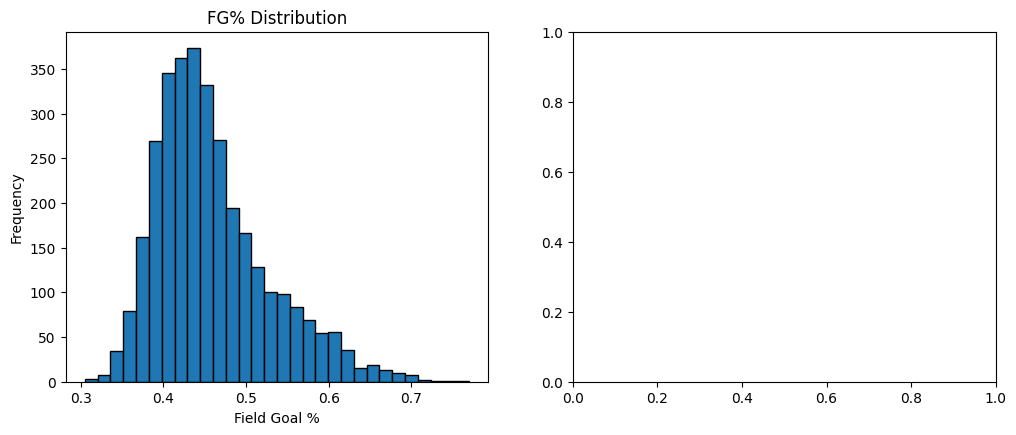

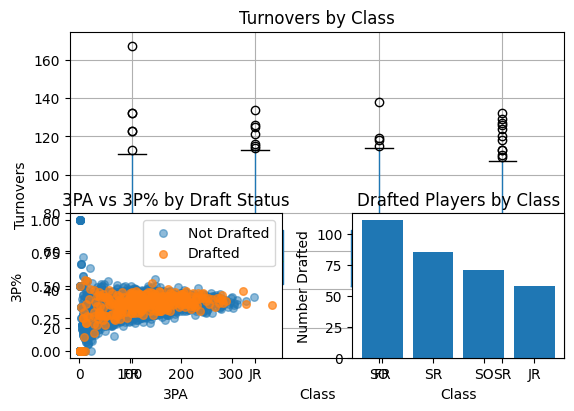

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create 3P% if not already present
if '3P%' not in ncaa.columns and '3P' in ncaa.columns and '3PA' in ncaa.columns:
    ncaa['3P%'] = np.where(ncaa['3PA'] > 0, ncaa['3P'] / ncaa['3PA'], np.nan)

# Split drafted vs not drafted
drafted = ncaa[ncaa['Drafted'] == 1]
not_drafted = ncaa[ncaa['Drafted'] == 0]

plt.figure(figsize=(12, 10))

# -------------------------
# Plot 1: Histogram FG%
# -------------------------
plt.subplot(2, 2, 1)
plt.hist(ncaa['FG%'].dropna(), bins=30, edgecolor='black')
plt.title('FG% Distribution')
plt.xlabel('Field Goal %')
plt.ylabel('Frequency')


# -------------------------
# Plot 2: Boxplot TOV by Class
# -------------------------
plt.subplot(2, 2, 2)
ncaa.boxplot(column='TOV', by='Class')
plt.title('Turnovers by Class')
plt.xlabel('Class')
plt.ylabel('Turnovers')
plt.suptitle('')


# -------------------------
# Plot 3: Scatter 3PA vs 3P%
# -------------------------
plt.subplot(2, 2, 3)

plt.scatter(not_drafted['3PA'], not_drafted['3P%'],
            alpha=0.5, label='Not Drafted', s=30)

plt.scatter(drafted['3PA'], drafted['3P%'],
            alpha=0.7, label='Drafted', s=30)

plt.title('3PA vs 3P% by Draft Status')
plt.xlabel('3PA')
plt.ylabel('3P%')
plt.legend()


# -------------------------
# Plot 4: Bar chart Drafted by Class
# -------------------------
plt.subplot(2, 2, 4)

counts = ncaa[ncaa['Drafted'] == 1]['Class'].value_counts()

plt.bar(counts.index.astype(str), counts.values)

plt.title('Drafted Players by Class')
plt.xlabel('Class')
plt.ylabel('Number Drafted')


# -------------------------
plt.tight_layout()
plt.show()

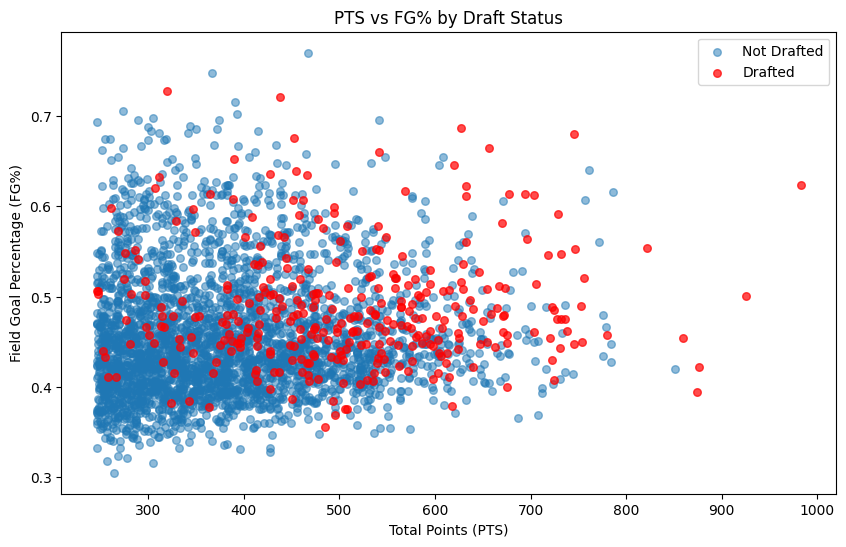

In [ ]:
# Color by draft status
drafted = ncaa[ncaa['Drafted'] == 1]
not_drafted = ncaa[ncaa['Drafted'] == 0]

plt.figure(figsize=(10, 6))

plt.scatter(not_drafted['PTS'], not_drafted['FG%'],
            alpha=0.5, label='Not Drafted', s=30)

plt.scatter(drafted['PTS'], drafted['FG%'],
            alpha=0.7, label='Drafted', s=30, color='red')

plt.xlabel('Total Points (PTS)')
plt.ylabel('Field Goal Percentage (FG%)')
plt.title('PTS vs FG% by Draft Status')

plt.legend()
plt.show()

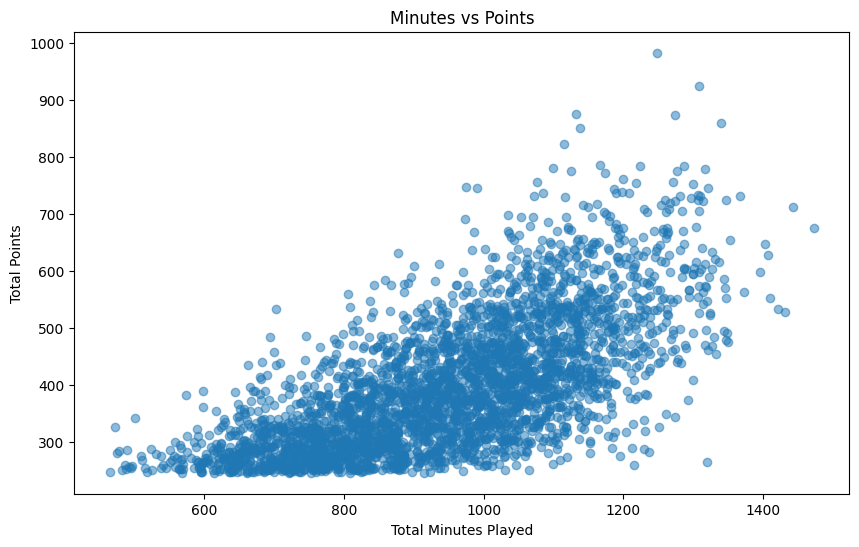

In [ ]:
# Do more minutes lead to more points?
plt.figure(figsize=(10, 6))
plt.scatter(ncaa['MP'], ncaa['PTS'], alpha=0.5)
plt.xlabel('Total Minutes Played')
plt.ylabel('Total Points')
plt.title('Minutes vs Points')
plt.show()

In [ ]:
import numpy as np

# 3P% if you have 3P and 3PA
if '3P%' not in ncaa.columns and '3P' in ncaa.columns and '3PA' in ncaa.columns:
    ncaa['3P%'] = np.where(ncaa['3PA'] > 0, ncaa['3P'] / ncaa['3PA'], np.nan)

# FG% sometimes is stored as string like "45.3%"
if 'FG%' in ncaa.columns and ncaa['FG%'].dtype == 'object':
    ncaa['FG%'] = ncaa['FG%'].astype(str).str.replace('%','', regex=False)
    ncaa['FG%'] = pd.to_numeric(ncaa['FG%'], errors='coerce') / 100

# Drafted should be 0/1 numeric
if 'Drafted' in ncaa.columns:
    ncaa['Drafted'] = pd.to_numeric(ncaa['Drafted'], errors='coerce')

In [ ]:
print(ncaa.columns.tolist())

['Player', 'Season', 'Team', 'GP', 'GS', 'MP', 'FG', 'FGA', '2P', '2PA', '3P', '3PA', 'FT', 'FTA', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'FG%', '2P%', '3P%', 'FT%', 'TS%', 'eFG%', 'POS', 'Class ', 'Drafted']


In [ ]:
model.score(X_test, y_test)

0.9119878603945372

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
X = ncaa[['PTS','FG%','3P','FT','TOV']]
y = ncaa['Drafted']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

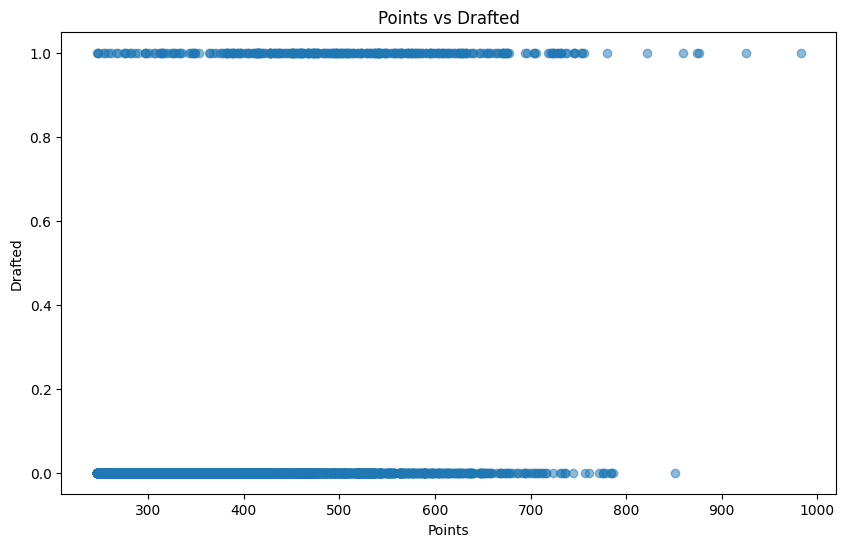

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(ncaa['PTS'], ncaa['Drafted'], alpha=0.5)
plt.xlabel("Points")
plt.ylabel("Drafted")
plt.title("Points vs Drafted")
plt.show()

In [ ]:
ncaa.corr(numeric_only=True)

,GP,GS,MP,FG,FGA,2P,2PA,3P,3PA,FT,...,TOV,PF,PTS,FG%,2P%,3P%,FT%,TS%,eFG%,Drafted
GP,1.000000,0.327260,0.542989,0.308138,0.278423,0.191789,0.182558,0.149777,0.142930,0.177896,...,0.138490,0.397094,0.309758,0.077054,0.088614,0.035196,-0.002767,0.118269,0.118338,0.109259
GS,0.327260,1.000000,0.685572,0.479594,0.467276,0.339563,0.371007,0.167102,0.169724,0.306573,...,0.339811,0.257657,0.475706,0.052620,0.042289,0.032095,0.021403,0.049076,0.040648,0.128859
MP,0.542989,0.685572,1.000000,0.607235,0.707274,0.279710,0.369285,0.453121,0.465636,0.426771,...,0.457661,0.160193,0.671963,-0.168110,-0.126719,0.124324,0.211583,-0.020663,-0.068324,0.189732
FG,0.308138,0.479594,0.607235,1.000000,0.874208,0.793917,0.803494,0.210317,0.198770,0.603491,...,0.469852,0.201057,0.947782,0.280013,0.248627,0.050976,0.050239,0.253485,0.232285,0.333101
FGA,0.278423,0.467276,0.707274,0.874208,1.000000,0.494488,0.631410,0.504729,0.539709,0.585990,...,0.521397,0.041680,0.923317,-0.201747,-0.177369,0.111318,0.238973,-0.115434,-0.164020,0.255398
2P,0.191789,0.339563,0.279710,0.793917,0.494488,1.000000,0.948776,-0.427453,-0.424181,0.541986,...,0.409802,0.348016,0.630589,0.607345,0.491845,-0.237684,-0.274316,0.247534,0.250178,0.262722
2PA,0.182558,0.371007,0.369285,0.803494,0.631410,0.948776,1.000000,-0.330851,-0.312036,0.618769,...,0.514530,0.295464,0.684474,0.366505,0.218738,-0.212489,-0.199354,0.010856,-0.010287,0.240904
3P,0.149777,0.167102,0.453121,0.210317,0.504729,-0.427453,-0.330851,1.000000,0.977570,0.025845,...,0.039683,-0.260629,0.395288,-0.560202,-0.421158,0.465153,0.515765,-0.021113,-0.056887,0.072841
3PA,0.142930,0.169724,0.465636,0.198770,0.539709,-0.424181,-0.312036,0.977570,1.000000,0.046192,...,0.080220,-0.269699,0.388150,-0.645067,-0.454780,0.382648,0.509210,-0.153213,-0.189788,0.051377
FT,0.177896,0.306573,0.426771,0.603491,0.585990,0.541986,0.618769,0.025845,0.046192,1.000000,...,0.541667,0.215341,0.747381,0.069244,0.006729,-0.028803,0.216688,0.141044,-0.086061,0.229729


<Figure size 1000x600 with 0 Axes>

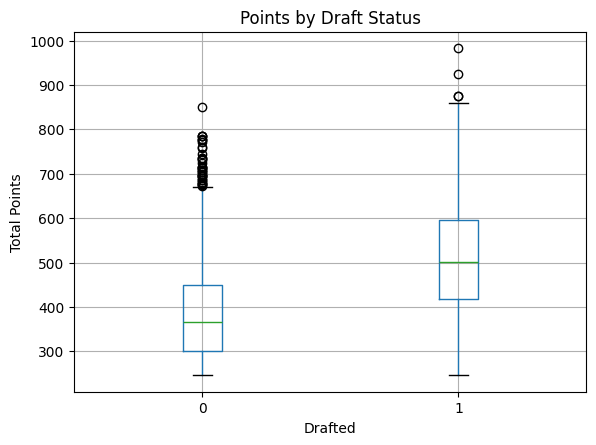

In [ ]:
plt.figure(figsize=(10, 6))
ncaa.boxplot(column='PTS', by='Drafted')
plt.suptitle('')
plt.xlabel('Drafted')
plt.ylabel('Total Points')
plt.title('Points by Draft Status')
plt.show()

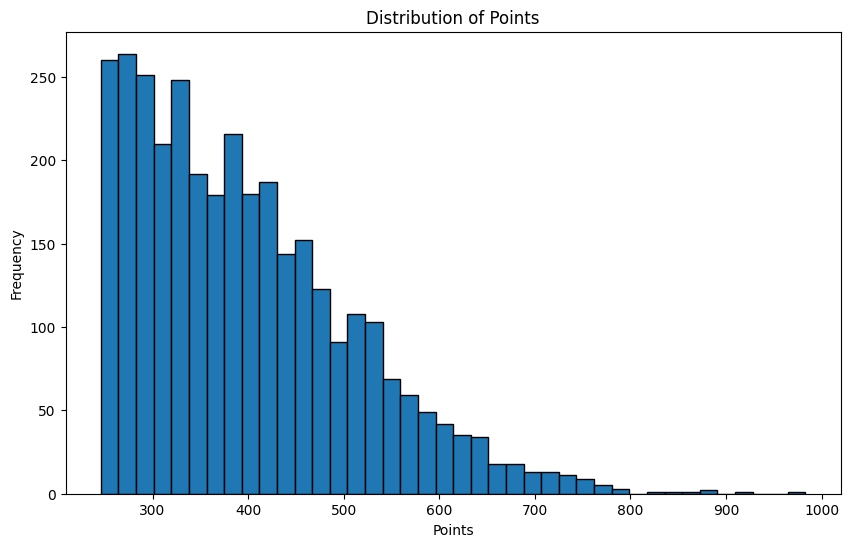

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(ncaa['PTS'], bins=40, edgecolor='black')
plt.title("Distribution of Points")
plt.xlabel("Points")
plt.ylabel("Frequency")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

Kentucky          22
Duke              21
UCLA              11
Gonzaga           11
Michigan          10
North Carolina    10
Kansas            10
Tennessee          9
Arizona            9
Villanova          9

In [ ]:
ncaa.groupby('POS')['Drafted'].mean().sort_values(ascending=False)

POS
F    0.116197
C    0.111842
G    0.087781
Name: Drafted, dtype: float64

In [ ]:
ncaa[ncaa['Drafted'] == 1]['Team'].value_counts().head(10)

Team
Kentucky          22
Duke              21
UCLA              11
Gonzaga           11
Michigan          10
North Carolina    10
Kansas            10
Tennessee          9
Arizona            9
Villanova          9
Name: count, dtype: int64

9.87 percent drafted


In [ ]:
draft_percentage = ncaa['Drafted'].mean() * 100
draft_percentage

np.float64(9.869419981779533)

In [ ]:
qualified = ncaa[ncaa['GP'] >= 20]

qualified.nlargest(10, 'PPG')[['Player', 'Team', 'PPG']]

,Player,Team,PPG
1308,Trae Young,Oklahoma,27.375000
3235,Zach Edey,Purdue,25.205128
1885,Markus Howard,Marquette,25.029412
3044,Buddy Hield,Oklahoma,25.000000
2633,Carsen Edwards,Purdue,24.277778
839,Luka Garza,Iowa,24.096774
677,Stefan Moody,Ole Miss,23.580645
1762,Anthony Barber,NC State,23.515152
2346,Keegan Murray,Iowa,23.485714
125,Markelle Fultz,Washington,23.160000


In [ ]:
ncaa.nlargest(10, 'PTS')[['Player', 'Team', 'PTS', 'PPG']]

,Player,Team,PTS,PPG
3235,Zach Edey,Purdue,983,25.205128
3044,Buddy Hield,Oklahoma,925,25.000000
1308,Trae Young,Oklahoma,876,27.375000
2633,Carsen Edwards,Purdue,874,24.277778
3147,R.J. Barrett,Duke,860,22.631579
1885,Markus Howard,Marquette,851,25.029412
2346,Keegan Murray,Iowa,822,23.485714
3030,Drew Timme,Gonzaga,786,21.243243
1844,Myles Powell,Seton Hall,784,23.058824
2956,RJ Davis,North Carolina,784,21.189189


In [ ]:
ncaa.groupby('Drafted')[['PPG', 'RPG', 'APG']].mean()

,PPG,RPG,APG
Drafted,,,
0,11.878479,4.573434,2.210155
1,15.026547,5.970683,2.645281


In [ ]:
ncaa.groupby('POS')['Drafted'].mean()

POS
C    0.111842
F    0.116197
G    0.087781
Name: Drafted, dtype: float64

In [ ]:
ncaa['POS'].value_counts()

POS
G    2005
F    1136
C     152
Name: count, dtype: int64

In [ ]:
ncaa.groupby('POS')[['PTS', 'AST', 'TRB']].mean()

,PTS,AST,TRB
POS,,,
C,394.638158,35.414474,235.907895
F,391.194542,47.459507,204.239437
G,401.839401,91.456858,119.769077


In [ ]:
ncaa['PPG'] = ncaa['PTS'] / ncaa['GP']
ncaa['RPG'] = ncaa['TRB'] / ncaa['GP']
ncaa['APG'] = ncaa['AST'] / ncaa['GP']

ncaa[['Player', 'PPG', 'RPG', 'APG']].head()

,Player,PPG,RPG,APG
0,James Bouknight,18.733333,5.666667,1.800000
1,Caris LeVert,16.466667,5.333333,4.933333
2,B.J. Taylor,15.875000,2.000000,3.187500
3,Emanuel Miller,16.235294,8.235294,1.411765
4,Dylan Disu,15.000000,9.235294,1.352941


In [ ]:
elite_guards = ncaa[(ncaa['POS'] == 'G') & (ncaa['PTS'] >= 400)]
elite_guards[['Player', 'PTS', 'POS']].head()

,Player,PTS,POS
41,Scotty Pippen Jr.,457,G
82,Remy Martin,440,G
88,Josh Okogie,437,G
98,Javon Freeman-Liberty,520,G
102,Nah'Shon Hyland,467,G


In [ ]:
high_scorers = ncaa[ncaa['PTS'] > 500]
print(f"High scorers: {len(high_scorers)}")

High scorers: 611


In [ ]:
scoring = ncaa[['Player', 'Team', 'PTS', 'GP']]
scoring.head()

,Player,Team,PTS,GP
0,James Bouknight,Connecticut,281,15
1,Caris LeVert,Michigan,247,15
2,B.J. Taylor,UCF,254,16
3,Emanuel Miller,Texas A&M,276,17
4,Dylan Disu,Vanderbilt,255,17


In [ ]:
ncaa.isna().sum()

Player       0
Season       0
Team         0
GP           0
GS           0
MP           0
FG           0
FGA          0
2P           0
2PA          0
3P           0
3PA          0
FT           0
FTA          0
ORB          0
DRB          0
TRB          0
AST          0
STL          0
BLK          0
TOV          0
PF           0
PTS          0
FG%          0
2P%          0
3P%        167
FT%          0
TS%          0
eFG%         0
POS          0
Class        0
Drafted      0
dtype: int64

In [ ]:
ncaa.columns

Index(['Player', 'Season', 'Team', 'GP', 'GS', 'MP', 'FG', 'FGA', '2P', '2PA',
       '3P', '3PA', 'FT', 'FTA', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK',
       'TOV', 'PF', 'PTS', 'FG%', '2P%', '3P%', 'FT%', 'TS%', 'eFG%', 'POS',
       'Class ', 'Drafted'],
      dtype='object')

In [ ]:
ncaa.describe()

,GP,GS,MP,FG,FGA,2P,2PA,3P,3PA,FT,...,TOV,PF,PTS,FG%,2P%,3P%,FT%,TS%,eFG%,Drafted
count,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,...,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3126.000000,3293.000000,3293.000000,3293.000000,3293.000000
mean,32.754327,27.775585,947.320377,139.908898,307.375949,99.655937,195.725478,40.252961,111.650471,77.764045,...,56.978743,70.353173,397.834801,0.459016,0.503231,0.338594,0.744838,0.558046,0.523156,0.098694
std,3.680110,9.000728,175.089721,40.279833,84.888148,43.558933,75.218870,27.090933,69.285879,35.682581,...,20.045229,18.366032,113.730216,0.068783,0.070751,0.102225,0.088795,0.048224,0.055262,0.298296
min,15.000000,0.000000,464.000000,72.000000,140.000000,9.000000,29.000000,0.000000,0.000000,11.000000,...,12.000000,18.000000,246.000000,0.305000,0.238000,0.000000,0.352000,0.408000,0.340000,0.000000
25%,31.000000,24.000000,817.000000,108.000000,242.000000,68.000000,141.000000,19.000000,60.000000,52.000000,...,42.000000,58.000000,305.000000,0.410000,0.455000,0.310000,0.689000,0.524000,0.484000,0.000000
50%,33.000000,31.000000,955.000000,133.000000,294.000000,94.000000,186.000000,40.000000,114.000000,71.000000,...,55.000000,70.000000,378.000000,0.445000,0.498000,0.352000,0.753000,0.555000,0.518000,0.000000
75%,35.000000,34.000000,1075.000000,164.000000,361.000000,125.000000,239.000000,58.000000,159.000000,96.000000,...,70.000000,83.000000,466.000000,0.494000,0.549000,0.389000,0.810000,0.589000,0.557000,0.000000
max,41.000000,41.000000,1474.000000,336.000000,703.000000,335.000000,537.000000,147.000000,380.000000,310.000000,...,167.000000,141.000000,983.000000,0.770000,0.770000,1.000000,0.984000,0.739000,0.770000,1.000000


In [ ]:
ncaa.shape

(3293, 32)

In [ ]:
ncaa.columns

Index(['Player', 'Season', 'Team', 'GP', 'GS', 'MP', 'FG', 'FGA', '2P', '2PA',
       '3P', '3PA', 'FT', 'FTA', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK',
       'TOV', 'PF', 'PTS', 'FG%', '2P%', '3P%', 'FT%', 'TS%', 'eFG%', 'POS',
       'Class ', 'Drafted'],
      dtype='object')

In [2]:
import pandas as pd

ncaa = pd.read_csv("Data/ncaa_data.csv")
ncaa.head()

,Player,Season,Team,GP,GS,MP,FG,FGA,2P,2PA,...,PTS,FG%,2P%,3P%,FT%,TS%,eFG%,POS,Class,Drafted
0,James Bouknight,2020-21,Connecticut,15,14,475,98,219,76,144,...,281,0.447,0.528,0.293,0.778,0.546,0.498,G,SO,1
1,Caris LeVert,2015-16,Michigan,15,14,464,82,162,53,97,...,247,0.506,0.546,0.446,0.794,0.636,0.596,G,SR,1
2,B.J. Taylor,2017-18,UCF,16,14,495,80,201,54,134,...,254,0.398,0.403,0.388,0.673,0.510,0.463,G,JR,0
3,Emanuel Miller,2020-21,Texas A&M,17,13,538,100,175,100,169,...,276,0.571,0.592,0.000,0.817,0.630,0.571,F,SO,0
4,Dylan Disu,2020-21,Vanderbilt,17,17,537,89,181,65,116,...,255,0.492,0.560,0.369,0.736,0.592,0.558,F,SO,0


In [3]:
ncaa['3P%'] = ncaa['3P%'].fillna(0)


In [4]:
# Check missing values
ncaa.isnull().sum()

# Show only columns with missing values
ncaa.isnull().sum()[ncaa.isnull().sum() > 0]

Series([], dtype: int64)

In [5]:
ncaa['PPG']  = ncaa['PTS'] / ncaa['GP']
ncaa['RPG']  = ncaa['TRB'] / ncaa['GP']
ncaa['APG']  = ncaa['AST'] / ncaa['GP']

In [8]:
ncaa['MP']  = ncaa['MP'] / ncaa['GP']
ncaa['STL']  = ncaa['STL'] / ncaa['GP']
ncaa['BLK']  = ncaa['BLK'] / ncaa['GP']
ncaa['TOV']  = ncaa['TOV'] / ncaa['GP']

In [11]:
ncaa ['3PAr'] = ncaa ['3PA'] / ncaa ['FGA']
ncaa ['FTr'] = ncaa ['FT'] / ncaa ['FG']

In [12]:
pos_map = {'G': 0, 'F': 1, 'C': 2}
ncaa['POS_enc'] = ncaa['POS'].map(pos_map)

In [14]:
ncaa ['Class '] = ncaa['Class '].str.strip()
class_map = { 'FR' : 0, 'SO' : 1, 'JR' : 2, 'SR' : 3}
ncaa['Class_enc'] = ncaa['Class '].map(class_map)

In [18]:
ncaa['GS_rate'] = ncaa['GS'] / ncaa['GP']

In [19]:
feature_cols = ['GP', 'GS', 'MP', 'FG', 'FGA', '2P', '2PA',
       '3P', '3PA', 'FT', 'FTA', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK',
       'TOV', 'PF', 'PTS', 'FG%', '2P%', '3P%', 'FT%', 'TS%', 'eFG%', 'GS_rate', 'PPG', 'RPG', 'APG', '3PAr', 'FTr'
    # your full list of columns here
]

X = ncaa[feature_cols]
y = ncaa['Drafted']

In [17]:
ncaa.columns

Index(['Player', 'Season', 'Team', 'GP', 'GS', 'MP', 'FG', 'FGA', '2P', '2PA',
       '3P', '3PA', 'FT', 'FTA', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK',
       'TOV', 'PF', 'PTS', 'FG%', '2P%', '3P%', 'FT%', 'TS%', 'eFG%', 'POS',
       'Class ', 'Drafted', 'PPG', 'RPG', 'APG', '3PAr', 'FTr', 'POS_enc',
       'Class_enc'],
      dtype='object')

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67, stratify=y
)

In [24]:
train = X_train.copy()
train['Drafted'] = y_train

test = X_test.copy()
test['Drafted'] = y_test

In [25]:
train.to_csv("Data/train.csv", index=False)
test.to_csv("Data/test.csv", index=False)